# descriptive.ipynb

This notebook calculated descriptive statistics in detail. The main notebook reports just a summary.

The `display_summary_table` and `plot_descriptive` functions below are called from the main notebook.

<br>
<br>

In [26]:
from IPython.display import display,Markdown 
import numpy as np
from scipy import stats
from matplotlib import pyplot as plt
import pandas as pd


def display_title(s, pref='Figure', num=1, center=False):
    ctag = 'center' if center else 'p'
    s    = f'<{ctag}><span style="font-size: 1.2em;"><b>{pref} {num}</b>: {s}</span></{ctag}>'
    if pref=='Figure':
        s = f'{s}<br><br>'
    else:
        s = f'<br><br>{s}'
    display( Markdown(s) )



Below the previously developed `parse_data.ipynb` notebook is run. See that notebook for details.

In [27]:
%run parse_data.ipynb

df.describe()


,Death Description,Mag,Focal Depth,Lat,Long
count,1348.000000,1348.000000,1348.000000,1348.000000,1348.000000
mean,1.612018,6.421958,30.352374,18.832711,35.772519
std,1.033976,0.964511,38.804668,21.297995,80.757761
min,1.000000,2.100000,0.000000,-54.000000,-178.252000
25%,1.000000,5.800000,10.000000,1.100000,-66.803250
50%,1.000000,6.400000,20.000000,25.324500,52.033500
75%,2.000000,7.100000,33.000000,36.802000,102.740750
max,4.000000,9.500000,651.000000,60.908000,178.291000


To create a custom display of descriptive statistics, let's first define functions that will calculate central tendency and dispersion metrics.

Refer also to [this notebook](https://github.com/0todd0000/OpenBook-DataAnalysisPracticeInPythonAndJupyter/blob/master/Lessons/Lesson04/5-Examples/DescriptiveStatsExamples.ipynb) for details regarding how create custom descriptive statistics tables.

In [28]:
def central(x, print_output=True):
    x0     = np.mean( x )
    x1     = np.median( x )
    x2     = stats.mode( x ).mode
    return x0, x1, x2


def dispersion(x, print_output=True):
    y0 = np.std( x )
    y1 = np.min( x )
    y2 = np.max( x )
    y3 = y2 - y1
    y4 = np.percentile( x, 25 )
    y5 = np.percentile( x, 75 )
    y6 = y5 - y4
    return y0,y1,y2,y3,y4,y5,y6

<br>

Let's now assemble and display a central tendency table:

</br>

In [29]:
def display_central_tendency_table(num=1):
    display_title('Central tendency summary statistics.', pref='Table', num=num, center=False)
    df_central = df.apply(lambda x: central(x), axis=0)

    round_dict = {'Death Description': 2, 'Mag': 2, 'Focal Depth': 2, 'Lat': 3, 'Long': 3}
    df_central = df_central.round( round_dict )
    row_labels = 'mean', 'median', 'mode'
    df_central.index = row_labels
    display( df_central )

display_central_tendency_table(num=1)

<br><br><p><span style="font-size: 1.2em;"><b>Table 1</b>: Central tendency summary statistics.</span></p>

,Death Description,Mag,Focal Depth,Lat,Long
mean,1.61,6.42,30.35,18.833,35.773
median,1.00,6.40,20.00,25.324,52.034
mode,1.00,6.10,10.00,36.000,-76.500


<br>

Let's repeat for a dispersion table:

</br>

In [30]:
def display_dispersion_table(num=1):
    display_title('Dispersion summary statistics.', pref='Table', num=num, center=False)
    round_dict = {'Death Description': 2, 'Mag': 2, 'Focal Depth': 2, 'Lat': 3, 'Long': 3}
    df_dispersion         = df.apply(lambda x: dispersion(x), axis=0).round( round_dict )
    row_labels_dispersion = 'st.dev.', 'min', 'max', 'range', '25th', '75th', 'IQR'
    df_dispersion.index   = row_labels_dispersion
    display( df_dispersion )

display_dispersion_table(num=2)


<br><br><p><span style="font-size: 1.2em;"><b>Table 2</b>: Dispersion summary statistics.</span></p>

,Death Description,Mag,Focal Depth,Lat,Long
st.dev.,1.03,0.96,38.79,21.290,80.728
min,1.00,2.10,0.00,-54.000,-178.252
max,4.00,9.50,651.00,60.908,178.291
range,3.00,7.40,651.00,114.908,356.543
25th,1.00,5.80,10.00,1.100,-66.803
75th,2.00,7.10,33.00,36.802,102.741
IQR,1.00,1.30,23.00,35.702,169.544


Let's save the variables in easier-to-use variable names:

In [31]:
dd   = df['Death Description']
mag  = df['Mag']
fd   = df['Focal Depth']
lat  = df['Lat']
lon  = df['Long']

Let's create scatterplots for the DV (Death Description) vs. each of IVs (Mag (magnitude), Focal Depth (km) (depth of earthquake focus in kilometers), Latitude (geographic latitude), Longitude (geographic longitude)):

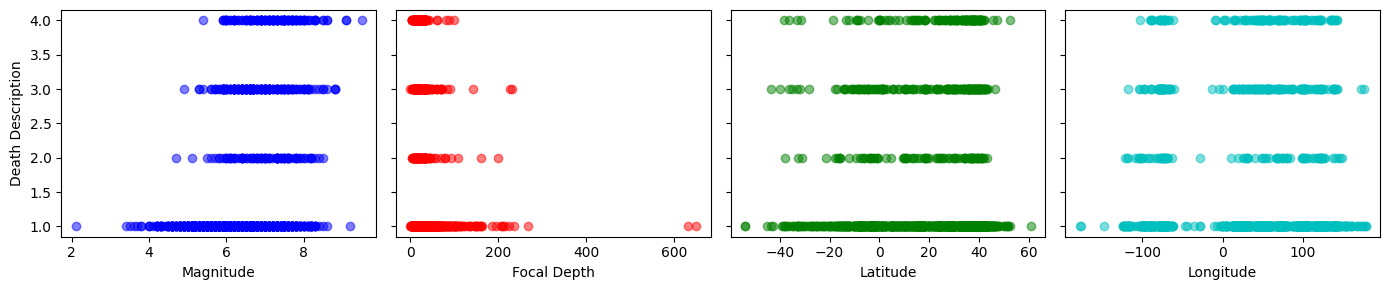

In [32]:
fig, axs = plt.subplots(1, 4, figsize=(14,3), tight_layout=True)
axs = axs.flatten()
axs[0].scatter(mag, dd, alpha=0.5, color='b')
axs[1].scatter(fd,  dd, alpha=0.5, color='r')
axs[2].scatter(lat, dd, alpha=0.5, color='g')
axs[3].scatter(lon, dd, alpha=0.5, color='c')

xlabels = 'Magnitude', 'Focal Depth', 'Latitude', 'Longitude'

[ax.set_xlabel(s) for ax,s in zip(axs,xlabels)]
axs[0].set_ylabel('Death Description')
[ax.set_yticklabels([])  for ax in axs[1:]]
plt.show()

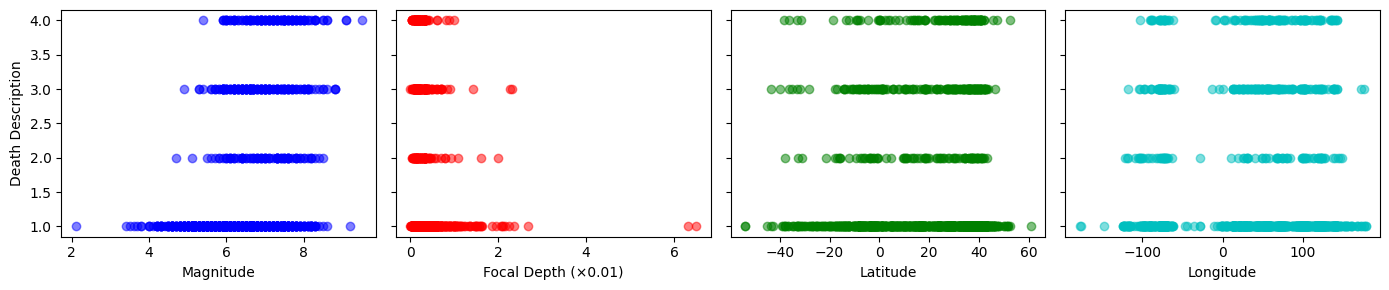

In [33]:
fd1 = np.around(fd / 100, 2)    # transformed focal depth value

fig, axs = plt.subplots(1, 4, figsize=(14, 3), tight_layout=True)

axs[0].scatter(mag, dd, alpha=0.5, color='b')
axs[1].scatter(fd1, dd, alpha=0.5, color='r')
axs[2].scatter(lat, dd, alpha=0.5, color='g')
axs[3].scatter(lon, dd, alpha=0.5, color='c')

xlabels = ['Magnitude', 'Focal Depth (×0.01)', 'Latitude', 'Longitude']
[ax.set_xlabel(s) for ax, s in zip(axs, xlabels)]

axs[0].set_ylabel('Death Description')
[ax.set_yticklabels([]) for ax in axs[1:]]

plt.show()

Next let's add regression lines and correlation coefficients to each plot:

In [34]:
def corrcoeff(x, y):
    r = np.corrcoef(x, y)[0,1]
    return r

def plot_regression_line(ax, x, y, **kwargs):
    a,b   = np.polyfit(x, y, deg=1)
    x0,x1 = min(x), max(x)
    y0,y1 = a*x0 + b, a*x1 + b
    ax.plot([x0,x1], [y0,y1], **kwargs)


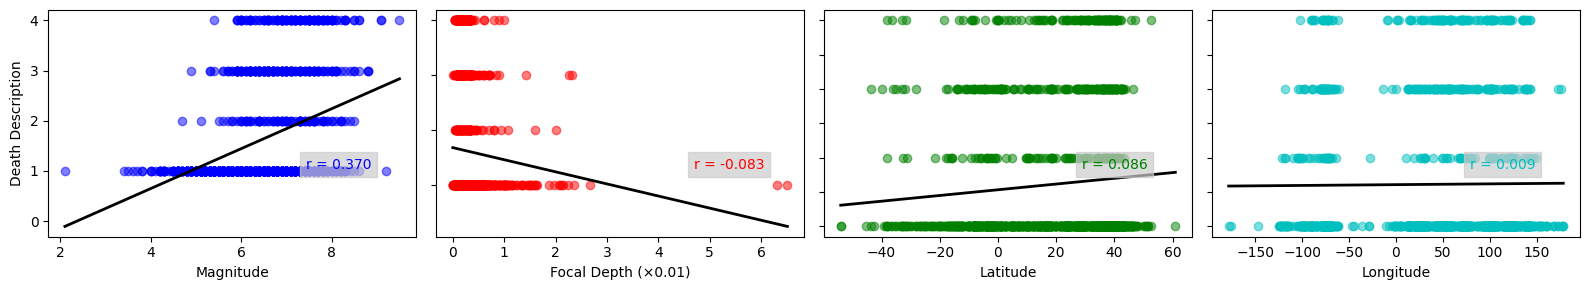

In [35]:
fig, axs = plt.subplots(1, 4, figsize=(16,3), tight_layout=True)
axs = axs.flatten()

ivs     = [mag, fd1, lat, lon]
colors  = ['b', 'r', 'g', 'c']

for ax, x, c in zip(axs, ivs, colors):
    ax.scatter(x, dd, alpha=0.5, color=c)
    plot_regression_line(ax, x, dd, color='k', ls='-', lw=2)
    r = corrcoeff(x, dd)
    ax.text(0.7, 0.3, f'r = {r:.3f}', color=c,
            transform=ax.transAxes,
            bbox=dict(color='0.8', alpha=0.7))

xlabels = [
    'Magnitude',
    'Focal Depth (×0.01)',
    'Latitude',
    'Longitude'
]

[ax.set_xlabel(s) for ax, s in zip(axs, xlabels)]

axs[0].set_ylabel('Death Description')
[ax.set_yticklabels([]) for ax in axs[1:]]

plt.show()

The correlation coefficients are all relatively low, suggesting no clear linear correlation between the DV and IVs.

However, in the magnitude data (right panel above) it appears that there may be opposite trends for low-mortality events (Death Description ≤ 2) and high-mortality events (Death Description ≥ 3). Let’s plot death description vs. magnitude separately for the low- and high-mortality groups, along with linear regression trends.

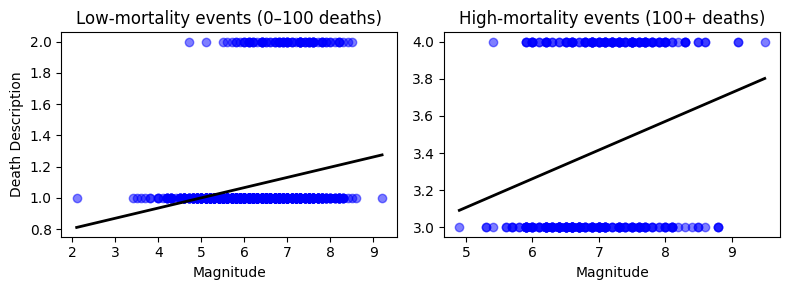

In [36]:

i_low  = dd <= 2     # 0–2 deaths category: none/few/some
i_high = dd >= 3     # 3–4 deaths category: many/very many

fig, axs = plt.subplots(1, 2, figsize=(8,3), tight_layout=True)

for ax, idx in zip(axs, [i_low, i_high]):
    ax.scatter(mag[idx], dd[idx], alpha=0.5, color='b')
    plot_regression_line(ax, mag[idx], dd[idx], color='k', ls='-', lw=2)

[ax.set_xlabel('Magnitude') for ax in axs]

axs[0].set_title('Low-mortality events (0–100 deaths)')
axs[0].set_ylabel('Death Description')
axs[1].set_title('High-mortality events (100+ deaths)')

plt.show()

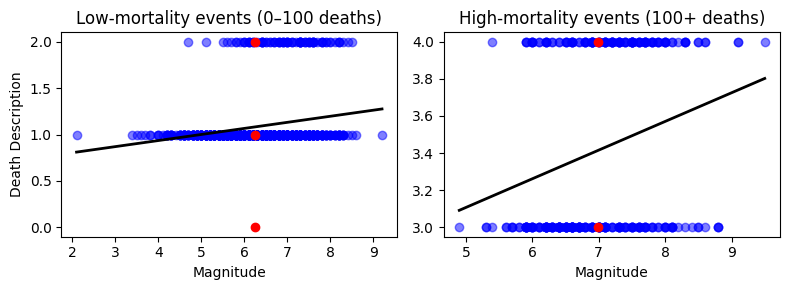

In [37]:
fig, axs = plt.subplots(1, 2, figsize=(8,3), tight_layout=True)

for ax, idx in zip(axs, [i_low, i_high]):
    ax.scatter(mag[idx], dd[idx], alpha=0.5, color='b')
    plot_regression_line(ax, mag[idx], dd[idx], color='k', ls='-', lw=2)

[axs[0].plot(mag[i_low].mean(), d, 'ro')  for d in [0, 1, 2]]
[axs[1].plot(mag[i_high].mean(), d, 'ro') for d in [3, 4]]

[ax.set_xlabel('Magnitude') for ax in axs]
axs[0].set_title('Low-mortality events (0–100 deaths)')
axs[0].set_ylabel('Death Description')
axs[1].set_title('High-mortality events (100+ deaths)')

plt.show()

These analyses show that the trends associated with just the means are unclear.

Let's now assemble all results into a single figure for reporting purposes:

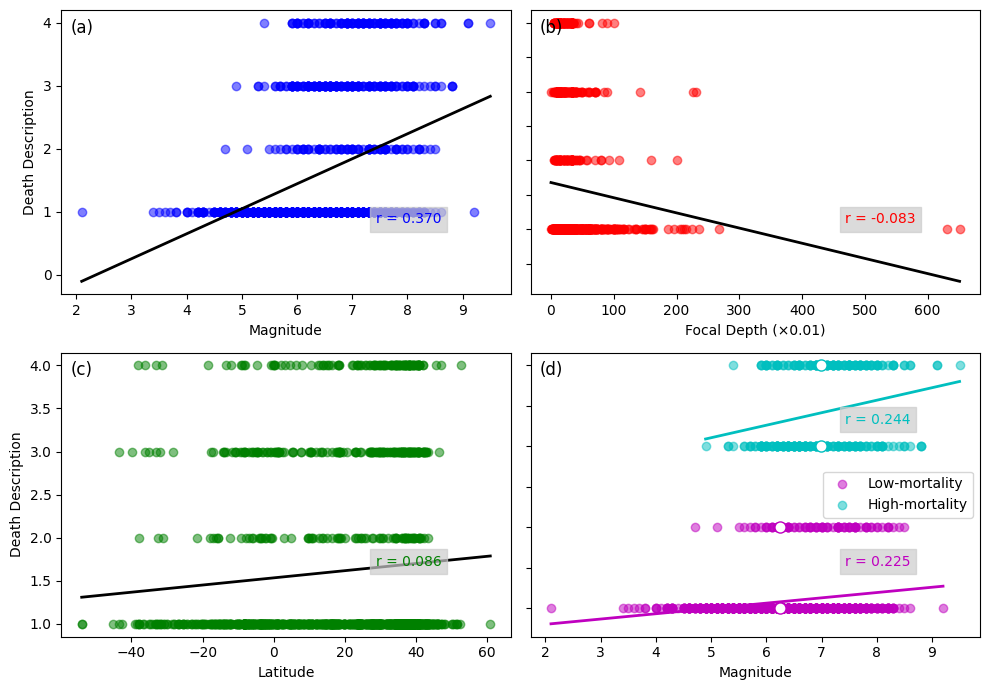

<p><span style="font-size: 1.2em;"><b>Figure 1</b>: Correlations among earthquake variables</span></p><br><br>

In [40]:
def plot_descriptive():

    fig, axs = plt.subplots(2, 2, figsize=(10,7), tight_layout=True)
    ivs      = [mag, fd, lat]
    colors   = ['b', 'r', 'g']

    for ax, x, c in zip(axs.ravel()[:3], ivs, colors):
        ax.scatter(x, dd, alpha=0.5, color=c)
        plot_regression_line(ax, x, dd, color='k', ls='-', lw=2)
        r = corrcoeff(x, dd)
        ax.text(0.70, 0.25, f'r = {r:.3f}', color=c,
                transform=ax.transAxes,
                bbox=dict(color='0.8', alpha=0.7))

    xlabels = ['Magnitude', 'Focal Depth (×0.01)', 'Latitude']
    for ax, label in zip(axs.ravel()[:3], xlabels):
        ax.set_xlabel(label)

    axs[0,0].set_ylabel("Death Description")
    axs[1,0].set_ylabel("Death Description")

    for ax in axs[:,1]:
        ax.set_yticklabels([])

    ax = axs[1,1]

    i_low  = dd <= 2
    i_high = dd >= 3

    groups      = [i_low, i_high]
    g_colors    = ['m', 'c']
    g_labels    = ['Low-mortality', 'High-mortality']
    q_groups    = [[1,2], [3,4]]
    ylocs       = [0.25, 0.75]

    for idx, color, label, qs, yloc in zip(groups, g_colors, g_labels, q_groups, ylocs):
        ax.scatter(mag[idx], dd[idx], alpha=0.5, color=color, label=label)
        plot_regression_line(ax, mag[idx], dd[idx], color=color, ls='-', lw=2)
        for q in qs:
            ax.plot(mag[idx].mean(), q, 'o', color=color, mfc='white', ms=8)
        r = corrcoeff(mag[idx], dd[idx])
        ax.text(0.70, yloc, f'r = {r:.3f}', color=color,
                transform=ax.transAxes,
                bbox=dict(color='0.8', alpha=0.7))

    ax.set_xlabel("Magnitude")
    ax.legend()

    panel_labels = ['a', 'b', 'c', 'd']
    for ax, s in zip(axs.ravel(), panel_labels):
        ax.text(0.02, 0.92, f'({s})', size=12, transform=ax.transAxes)

    plt.show()

    display_title('Correlations among earthquake variables', pref='Figure', num=1)


plot_descriptive()